In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-reviews/Cell_Phones_and_Accessories_5.json


In [2]:
file_path = "/kaggle/input/amazon-reviews/Cell_Phones_and_Accessories_5.json"
df = pd.read_json(file_path, lines=True)
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"


In [3]:
df.shape

(194439, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194439 entries, 0 to 194438
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   reviewerID      194439 non-null  object
 1   asin            194439 non-null  object
 2   reviewerName    190920 non-null  object
 3   helpful         194439 non-null  object
 4   reviewText      194439 non-null  object
 5   overall         194439 non-null  int64 
 6   summary         194439 non-null  object
 7   unixReviewTime  194439 non-null  int64 
 8   reviewTime      194439 non-null  object
dtypes: int64(2), object(7)
memory usage: 13.4+ MB


In [5]:
df.isnull().sum()

reviewerID           0
asin                 0
reviewerName      3519
helpful              0
reviewText           0
overall              0
summary              0
unixReviewTime       0
reviewTime           0
dtype: int64

In [6]:
df['reviewerName'] = df['reviewerName'].fillna('Unknown')

In [7]:
df.isnull().sum()

reviewerID        0
asin              0
reviewerName      0
helpful           0
reviewText        0
overall           0
summary           0
unixReviewTime    0
reviewTime        0
dtype: int64

In [8]:
non_list_cols = df.columns[df.dtypes != 'object'].tolist()
non_list_cols += ['reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'reviewTime']
print("Duplicate rows (excluding 'helpful'):", df.duplicated(subset=non_list_cols).sum())

Duplicate rows (excluding 'helpful'): 0


In [9]:
def map_sentiment(rating):
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

df['sentiment'] = df['overall'].apply(map_sentiment)

print('Sentiment class distribution:')
print(df['sentiment'].value_counts())

Sentiment class distribution:
sentiment
2    148657
0     24343
1     21439
Name: count, dtype: int64


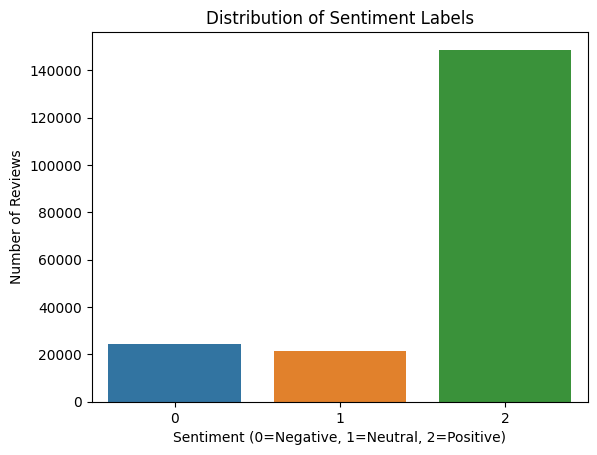

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment (0=Negative, 1=Neutral, 2=Positive)')
plt.ylabel('Number of Reviews')
plt.show()

In [11]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

df['cleaned_text'] = df['reviewText'].apply(clean_text)
df[['reviewText', 'cleaned_text']].head()


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,reviewText,cleaned_text
0,They look good and stick good! I just don't li...,look good stick good dont like rounded shape a...
1,These stickers work like the review says they ...,sticker work like review say stick great stay ...
2,These are awesome and make my phone look so st...,awesome make phone look stylish used one far a...
3,Item arrived in great time and was in perfect ...,item arrived great time perfect condition howe...
4,"awesome! stays on, and looks great. can be use...",awesome stay look great used multiple apple pr...


In [12]:
# A TF-IDF + Logistic Regression Pipeline

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Split data
X = df['cleaned_text']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred = lr_model.predict(X_test_tfidf)

print("Classification Report (TF - IDF + LR):")
print(classification_report(y_test, y_pred))

Classification Report (TF - IDF + LR):
              precision    recall  f1-score   support

           0       0.68      0.58      0.63      4869
           1       0.45      0.17      0.25      4288
           2       0.87      0.96      0.91     29731

    accuracy                           0.83     38888
   macro avg       0.67      0.57      0.60     38888
weighted avg       0.80      0.83      0.80     38888



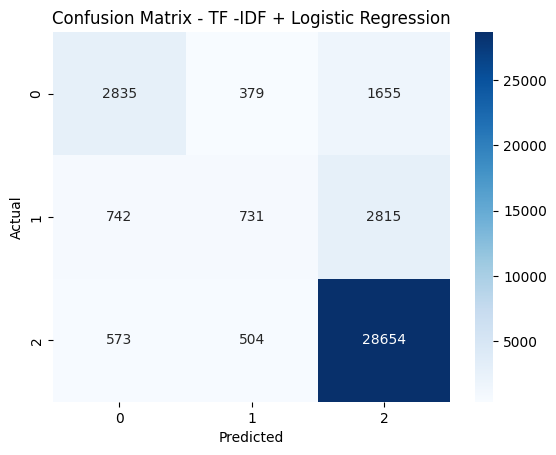

In [13]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt ='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix - TF -IDF + Logistic Regression")
plt.show()

In [14]:
from sklearn.metrics import accuracy_score

print(" Accuracy:", accuracy_score(y_test, y_pred))


 Accuracy: 0.8285332236165398


In [15]:
import joblib

# Save the vectorizer and model
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(lr_model, 'logistic_regression_model.pkl')

print(" Model and vectorizer saved.")


 Model and vectorizer saved.


In [16]:
# B Word2Vec + Classifier

# Tokenize for Word2Vec

from nltk.tokenize import word_tokenize
df['tokens'] = df['cleaned_text'].apply(word_tokenize)
df['tokens'].head()

0    [look, good, stick, good, dont, like, rounded,...
1    [sticker, work, like, review, say, stick, grea...
2    [awesome, make, phone, look, stylish, used, on...
3    [item, arrived, great, time, perfect, conditio...
4    [awesome, stay, look, great, used, multiple, a...
Name: tokens, dtype: object

In [17]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=5, workers=4, sg=1)
w2v_model.save("word2vec_amazon_model")

In [18]:
def average_vector(tokens, model, k=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(k)
    else:
        return np.mean(vectors, axis=0)

df['w2v_vector'] = df['tokens'].apply(lambda x: average_vector(x, w2v_model))
    

In [19]:
from sklearn.ensemble import RandomForestClassifier

X_w2v = np.stack(df['w2v_vector'].values)
y = df['sentiment']
# Split data
X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(X_w2v, y, test_size=0.2, stratify=y, random_state=42)


# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_w2v, y_train)

# predict
y_pred_rf = rf_model.predict(X_test_w2v)

# Evaluate
print("Classification Report (Word2Vec + RF):")
print(classification_report(y_test, y_pred_rf))

Classification Report (Word2Vec + RF):
              precision    recall  f1-score   support

           0       0.70      0.30      0.42      4869
           1       0.43      0.01      0.02      4288
           2       0.80      0.99      0.89     29731

    accuracy                           0.79     38888
   macro avg       0.65      0.43      0.44     38888
weighted avg       0.75      0.79      0.73     38888



In [20]:
print(" Accuracy:", accuracy_score(y_test, y_pred_rf))

 Accuracy: 0.7948467393540424


In [21]:
import joblib
joblib.dump(rf_model, "rf_word2vec_model.pkl")


['rf_word2vec_model.pkl']